In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('diamonds.csv')
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df1 = df.groupby('cut')['price'].sum().reset_index()
df1

,cut,price
0,Fair,7017600
1,Good,19275009
2,Ideal,74513487
3,Premium,63221498
4,Very Good,48107623


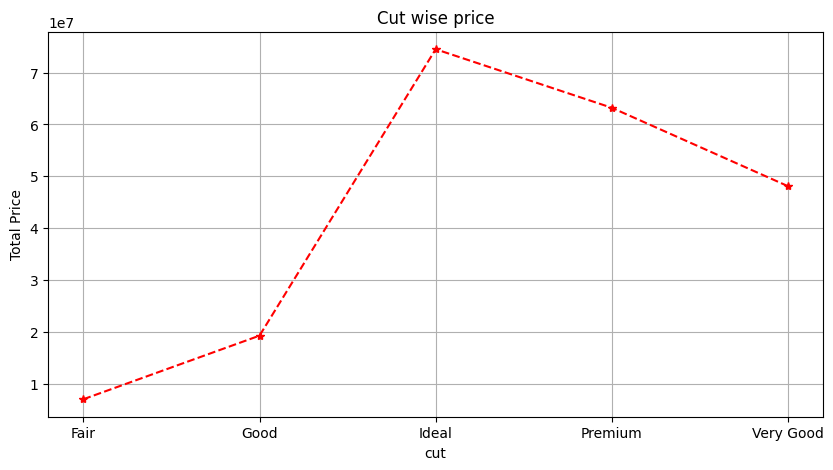

In [4]:
plt.figure(figsize=(10,5))
plt.plot(df1['cut'],df1['price'],marker="*",color='red',linestyle='--')#
plt.title("Cut wise price")
plt.xlabel("cut")
plt.grid(True)
plt.ylabel("Total Price")
plt.show()

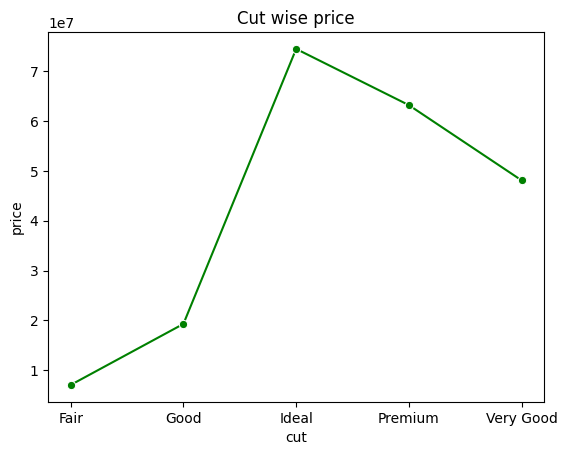

In [5]:
sns.lineplot(data=df1, x=df1['cut'],y=df1['price'], marker='o', color='green')#
plt.title("Cut wise price")
plt.show()

In [6]:
df2 = df.groupby('carat')['price'].sum().reset_index()
df2

,carat,price
0,0.20,4382
1,0.21,3422
2,0.22,1957
3,0.23,142440
4,0.24,128317
...,...,...
268,4.00,15984
269,4.01,30446
270,4.13,17329
271,4.50,18531


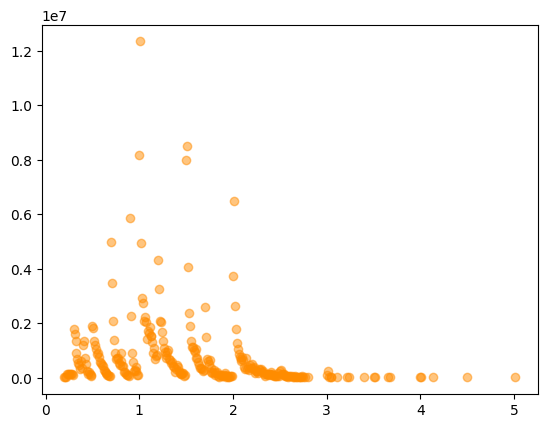

In [7]:
plt.scatter(df2['carat'], df2['price'],alpha=0.5,color='darkorange')#

<Axes: xlabel='carat', ylabel='price'>

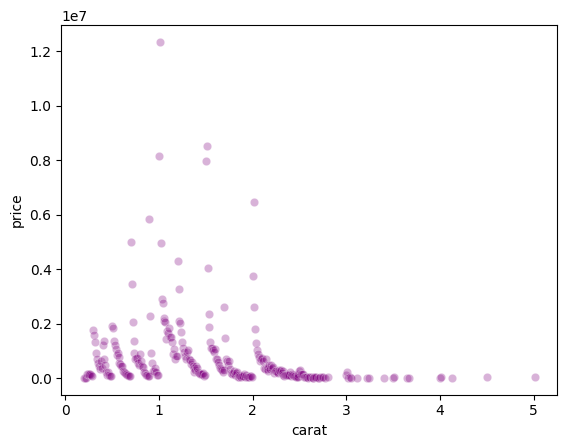

In [8]:
sns.scatterplot(data=df2, x='carat', y='price', alpha=0.3, color='purple')#

<BarContainer object of 5 artists>

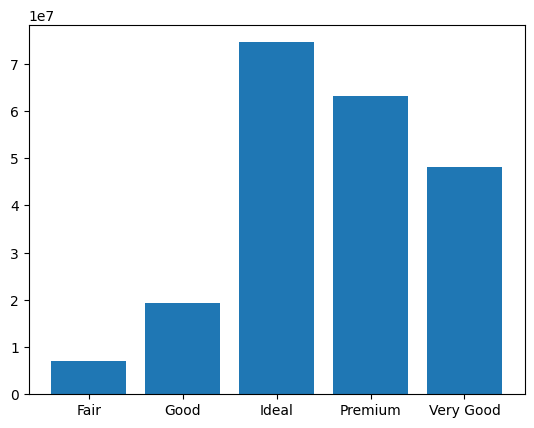

In [9]:
plt.bar(df1['cut'], df1['price'])

In [10]:
df3 = df.groupby(['color','cut'])['price'].sum().reset_index()
df3

,color,cut,price
0,D,Fair,699443
1,D,Good,2254363
2,D,Ideal,7450854
3,D,Premium,5820962
4,D,Very Good,5250817
5,E,Fair,824838
6,E,Good,3194260
7,E,Ideal,10138238
8,E,Premium,8270443
9,E,Very Good,7715165


<Axes: xlabel='color', ylabel='price'>

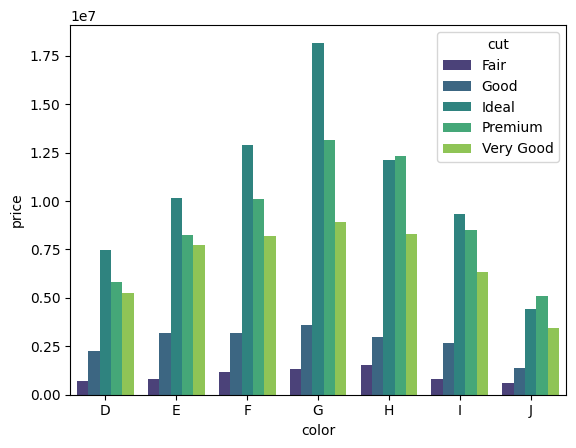

In [11]:
sns.barplot(data=df3, x='color', y='price',hue='cut', palette='viridis') #

In [12]:
cut_counts = df['cut'].value_counts()
cut_counts

,count
cut,
Ideal,21551
Premium,13791
Very Good,12082
Good,4906
Fair,1610


In [13]:
df1

,cut,price
0,Fair,7017600
1,Good,19275009
2,Ideal,74513487
3,Premium,63221498
4,Very Good,48107623


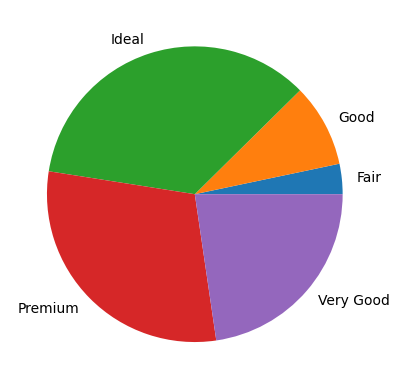

In [14]:
plt.pie(df1['price'], labels=df1['cut'])
plt.show()

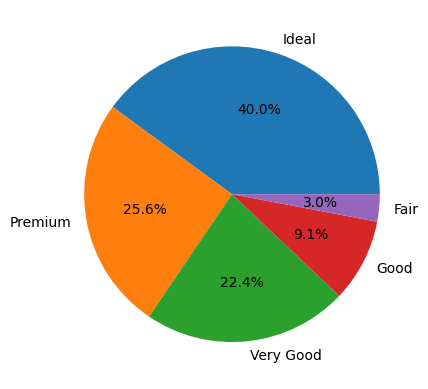

In [16]:
plt.pie(cut_counts, labels=cut_counts.index, autopct='%1.1f%%')
plt.show()

In [ ]:
df0 = pd.crosstab(df['cut'],df['color'])
df0

color,D,E,F,G,H,I,J
cut,,,,,,,
Fair,163,224,312,314,303,175,119
Good,662,933,909,871,702,522,307
Ideal,2834,3903,3826,4884,3115,2093,896
Premium,1603,2337,2331,2924,2360,1428,808
Very Good,1513,2400,2164,2299,1824,1204,678


In [ ]:
df01 = pd.pivot_table(df, values='price', index='color',columns=['clarity'], aggfunc="mean")
df01

clarity,I1,IF,SI1,SI2,VS1,VS2,VVS1,VVS2
color,,,,,,,,
D,3863.023810,8307.369863,2976.146423,3931.101460,3030.158865,2587.225692,2947.912698,3351.128391
E,3488.421569,3668.506329,3161.838005,4173.826036,2856.294301,2750.941700,2219.820122,2499.674067
F,3342.181818,2750.836364,3714.225716,4472.625233,3796.717742,3756.795093,2804.276567,3475.512821
G,3545.693333,2558.033774,3774.787449,5021.684109,4131.362197,4416.256498,2866.820821,3845.283437
H,4453.413580,2287.869565,5032.414945,6099.895074,3780.688623,4722.414486,1845.658120,2649.067434
I,4302.184783,1994.937063,5355.019663,7002.649123,4633.183992,5690.505560,2034.861972,2968.232877
J,5254.060000,3363.882353,5186.048000,6520.958246,4884.461255,5311.058824,4034.175676,5142.396947


In [ ]:
heatmap_data = df.groupby(['cut', 'color'])['price'].count().unstack()
heatmap_data

color,D,E,F,G,H,I,J
cut,,,,,,,
Fair,163,224,312,314,303,175,119
Good,662,933,909,871,702,522,307
Ideal,2834,3903,3826,4884,3115,2093,896
Premium,1603,2337,2331,2924,2360,1428,808
Very Good,1513,2400,2164,2299,1824,1204,678


<Axes: xlabel='color', ylabel='cut'>

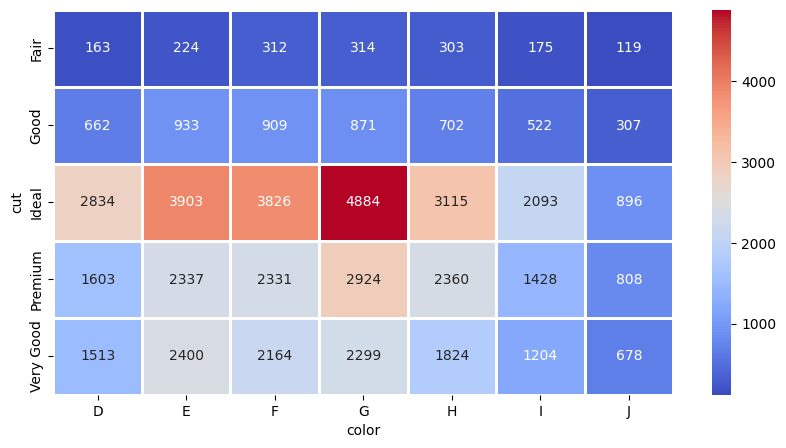

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(heatmap_data, cmap='coolwarm',  annot=True, fmt='d',  linewidths=1)#) #fmt='.2f' (2 dec) fmt='.0f'(round dec) fmt='%.1f%%' (%), 's' (strning) , 'e' sci

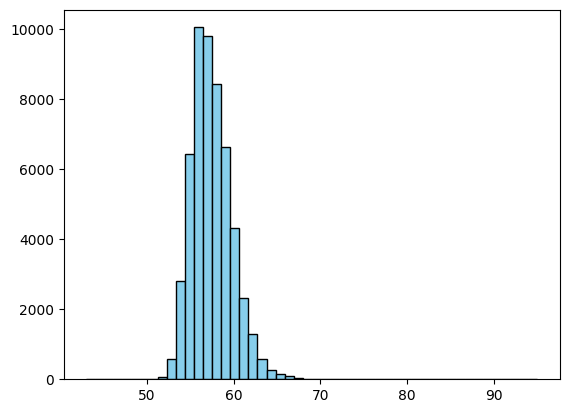

In [ ]:
plt.hist(df['table'], bins=50,color='skyblue', edgecolor='black')#)
plt.show()

<Axes: xlabel='price', ylabel='Count'>

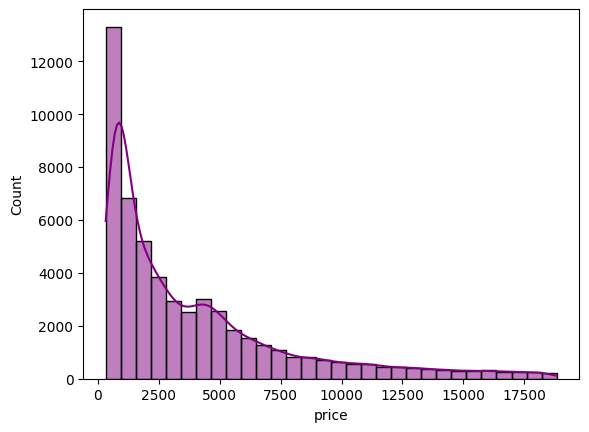

In [ ]:
sns.histplot(df['price'], bins=30, color='purple', kde=True)#

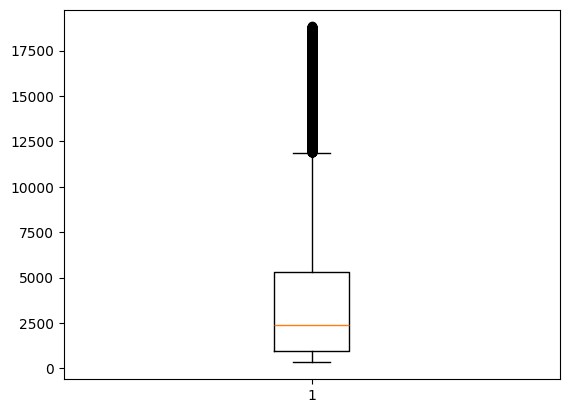

In [ ]:
plt.boxplot(df['price'])
plt.show()

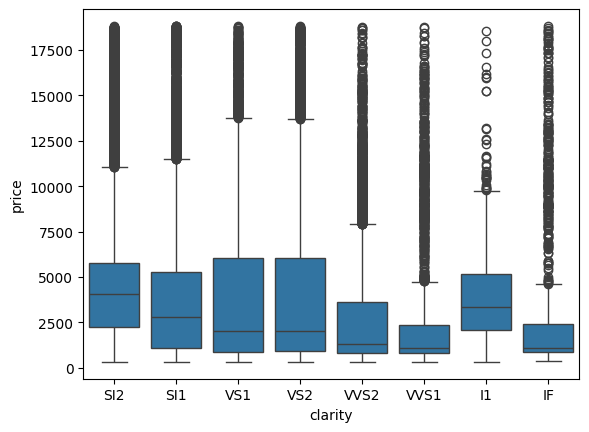

In [ ]:
sns.boxplot(x='clarity', y='price', data=df)#, palette='coolwarm'
plt.show()

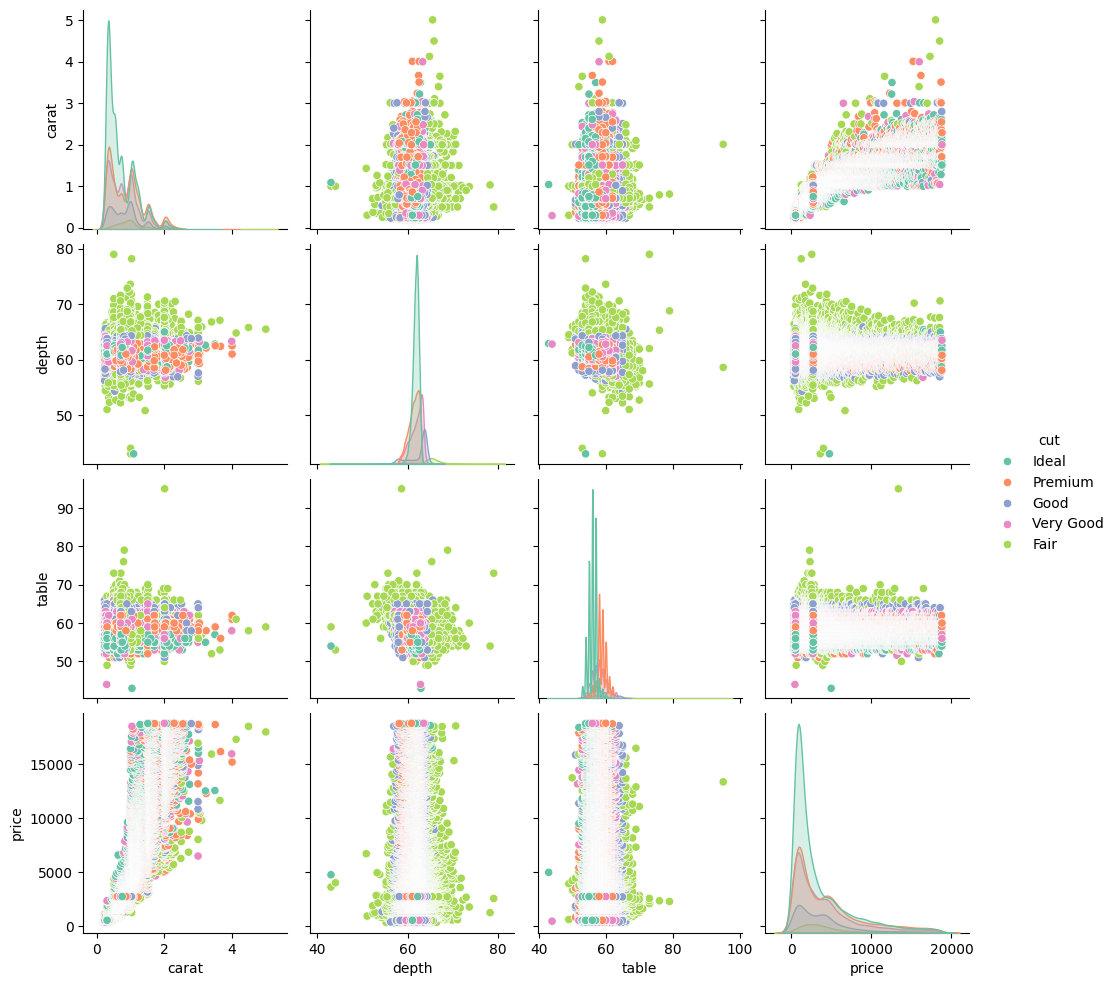

In [ ]:
sns.pairplot(df, vars=['carat', 'depth', 'table', 'price'], palette='Set2',hue='cut')#,
plt.show()

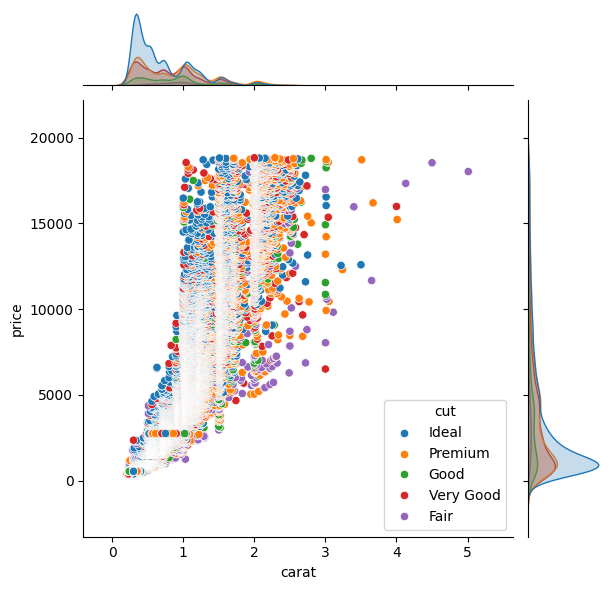

In [ ]:
#X= [1,2,3,4,5,6,7,8,9]
#y= [2,4,6,8,10,12,14,16,18]
#df_new = pd.DataFrame({'X':X,'Y':y})#
#sns.jointplot(data=df_new, x='X', y='Y', kind='scatter')
sns.jointplot(data=df, x='carat', y='price', kind='scatter', hue='cut')

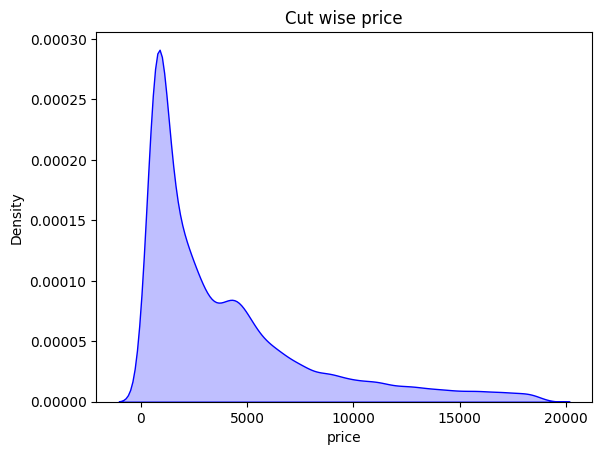

In [ ]:
sns.kdeplot(data=df, x='price', color='blue',fill=True)
plt.title("Cut wise price")
plt.show()

/tmp/ipython-input-2711045222.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='color', y='price', data=df, palette='Set2')


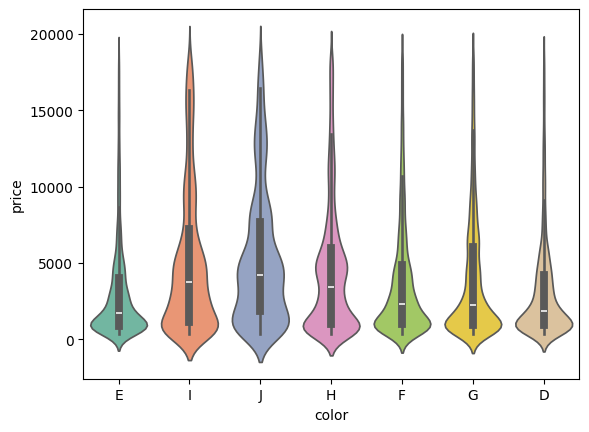

In [ ]:
sns.violinplot(x='color', y='price', data=df, palette='Set2')
plt.show()